## Overview 

The aim of this notebook is to manually test a new take on transient PL. The goal is to run a transient simulation that switches from SC to OC once the system has reached a SC steady-state. I used the basic device from the website and will now create a tVG file manually to run the experiment. 

Note: To perform these tests, the first V value in the tVG is 0 to get the SC steady state. The second is a transition step to 1V after 0.1 seconds. The third is where we finally reach Voc at t=0.2. For most of the graphs below, we will not plot the first two timesteps

In [1]:
import os, sys
import numpy as np
import typing 
from numbers import Number
import itertools as it
from dataclasses import dataclass
import pandas as pd
import matplotlib.pyplot as plt
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../..')
    import pySIMsalabim as sim

In [2]:
# Load results 
session_path = os.path.join("../../", "SIMsalabim/ZimT")
data = pd.read_csv(os.path.join(session_path, "tj.dat"), sep=r"\s+")

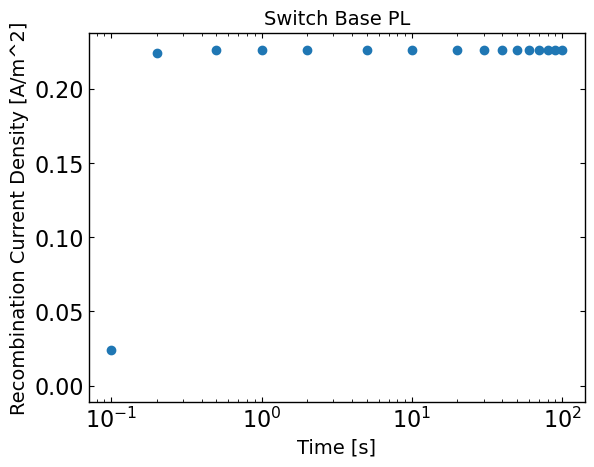

In [3]:
plt.scatter(data["t"], data["JdirL2"])
plt.xscale('log')
plt.xlabel("Time [s]")
plt.ylabel("Recombination Current Density [A/m^2]")
plt.title("Switch Base PL")
plt.show()

Now that we've tested to make sure this works, I think I may try varing some parameters to see if I can get a kick.

## Multiple runs for varying Ion Densities

For all the runs below, both mu_anion and mu_cation = 1E-11 but with varying densities.

In [4]:
N_ion = ["3E21", "4E21", "5E21", "6E21", "7E21", "8E21", "9E21", "1E22", "2E22", "3E22"]

In [5]:
float(N_ion[0])

3e+21

In [6]:
@dataclass
class ZimtRun:
    N_anion: Number
    N_cation: Number
    mu_anion: Number
    mu_cation: Number
    tj_data: pd.DataFrame

In [7]:
zimt_runs = []

for ion_density in N_ion:
    tj_file_name = f"tj_N_ion_{ion_density}.dat"
    tj_file_data = pd.read_csv(os.path.join(session_path, tj_file_name), sep=r"\s+")
    var_file_name = f'varFile_{ion_density}.dat'
    zimt_run = ZimtRun(N_anion=float(ion_density), N_cation=float(ion_density), tj_data=tj_file_data, mu_anion=1E-11, mu_cation=1E-11)
    zimt_runs.append(zimt_run)

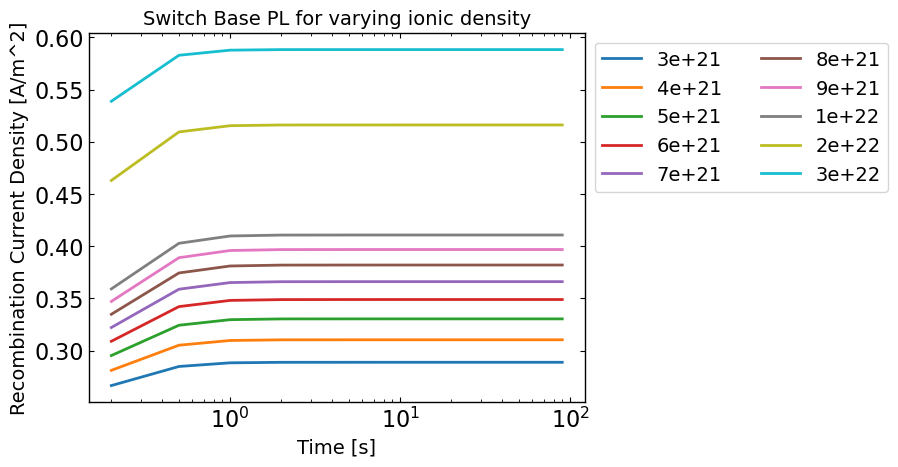

In [8]:
for zimt_run in zimt_runs:
    plt.plot(zimt_run.tj_data["t"][2:-1], zimt_run.tj_data["JdirL2"][2:-1], label=zimt_run.N_anion)

plt.xscale('log')
plt.xlabel("Time [s]")
plt.ylabel("Recombination Current Density [A/m^2]")
plt.title("Switch Base PL for varying ionic density")
plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.show()

There still doesn't seem to be anything in the way of a kick-back here. Jan Anton has suggested decreasing the ion mobilites to see if this results in a more noticable overshoot.

## Testing the effects of decreasing ion mobility
For this test:
- Mobilities will be kept equal for both anions and cations at 1E22
- I will vary mobilities from 1E-11 to 1E-15.

I would also like to increase the resolution in time immediately after the switch to OC, which I will do here.

In [9]:
tVG_filename = 'tVG_high_res.dat'

# Script to write a tVG file
tVG_header = 't Vext G_frac\n'
tVG_short_circuit_steady_state = '0 0 1\n'

# To reduce the internal displacement current, we add an intermidiate transition step to OC
tVG_transition_step = '0.1 1 1\n'

# From this point, we want logarithmically spaced timesteps
tVG_oc_steady_state = ''
for time in np.geomspace(2E-1, 1E4, 100):
    tVG_oc_steady_state += f'{time} oc 1\n'
    
# Define an OC steady state to add to the file at the end of the time column 
tVG_open_circuit_steady_state = '0 oc 1\n'

tVG_file_string = tVG_header + tVG_short_circuit_steady_state + tVG_transition_step + tVG_oc_steady_state + tVG_open_circuit_steady_state
    
# Write the tVG lines to the tVG file
with open(os.path.join(session_path,tVG_filename), 'w') as file:
    file.write(tVG_file_string)

In [10]:
mu_ions = [1E-11, 1E-12, 1E-13, 1E-14, 1E-15]

In [11]:
@dataclass
class ZimtRun:
    N_anion: Number
    N_cation: Number
    mu_anion: Number
    mu_cation: Number
    tj_data: pd.DataFrame
    var_data: pd.DataFrame

In [12]:
# Read in data 
zimt_runs = []

for ion_mobility in mu_ions:
    tj_file_name = f"tj_mu_ions_{ion_mobility}.dat"
    tj_file_data = pd.read_csv(os.path.join(session_path, tj_file_name), sep=r"\s+")
    
    var_file_name = f"varFile_{ion_mobility}.dat"
    var_file_data = pd.read_csv(os.path.join(session_path, var_file_name), sep=r"\s+")
    var_file_data = var_file_data[["x", "time", "n", "p", "anion", "cation", "V"]]
    
    zimt_run = ZimtRun(N_anion=1E22, N_cation=1E22, tj_data=tj_file_data, var_data=var_file_data, mu_anion=float(ion_mobility), mu_cation=float(ion_mobility))
    zimt_runs.append(zimt_run)

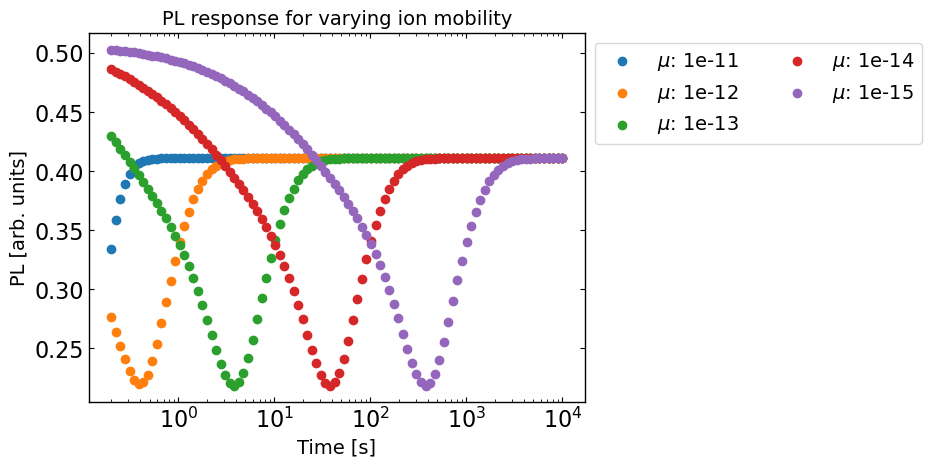

In [13]:
# Plot PL data for each mobility against time
for index, zimt_run in enumerate(zimt_runs):    
    label = f"$\\mu$: {zimt_run.mu_anion}"
    # Plot the final JdirL2 value, the OC steady state, as an asymptote
    plt.scatter(zimt_run.tj_data["t"][2:-1], zimt_run.tj_data["JdirL2"][2:-1], label=label)
    
plt.xscale('log')
# plt.axvline(0.1, linestyle='--', color='black') # Mark the initial voltage step
# plt.axvline(0.2, linestyle='--', color='black') # Mark the completion of the transition to Voc
plt.xlabel("Time [s]")
plt.ylabel("PL [arb. units]")
plt.title("PL response for varying ion mobility")
plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.show()

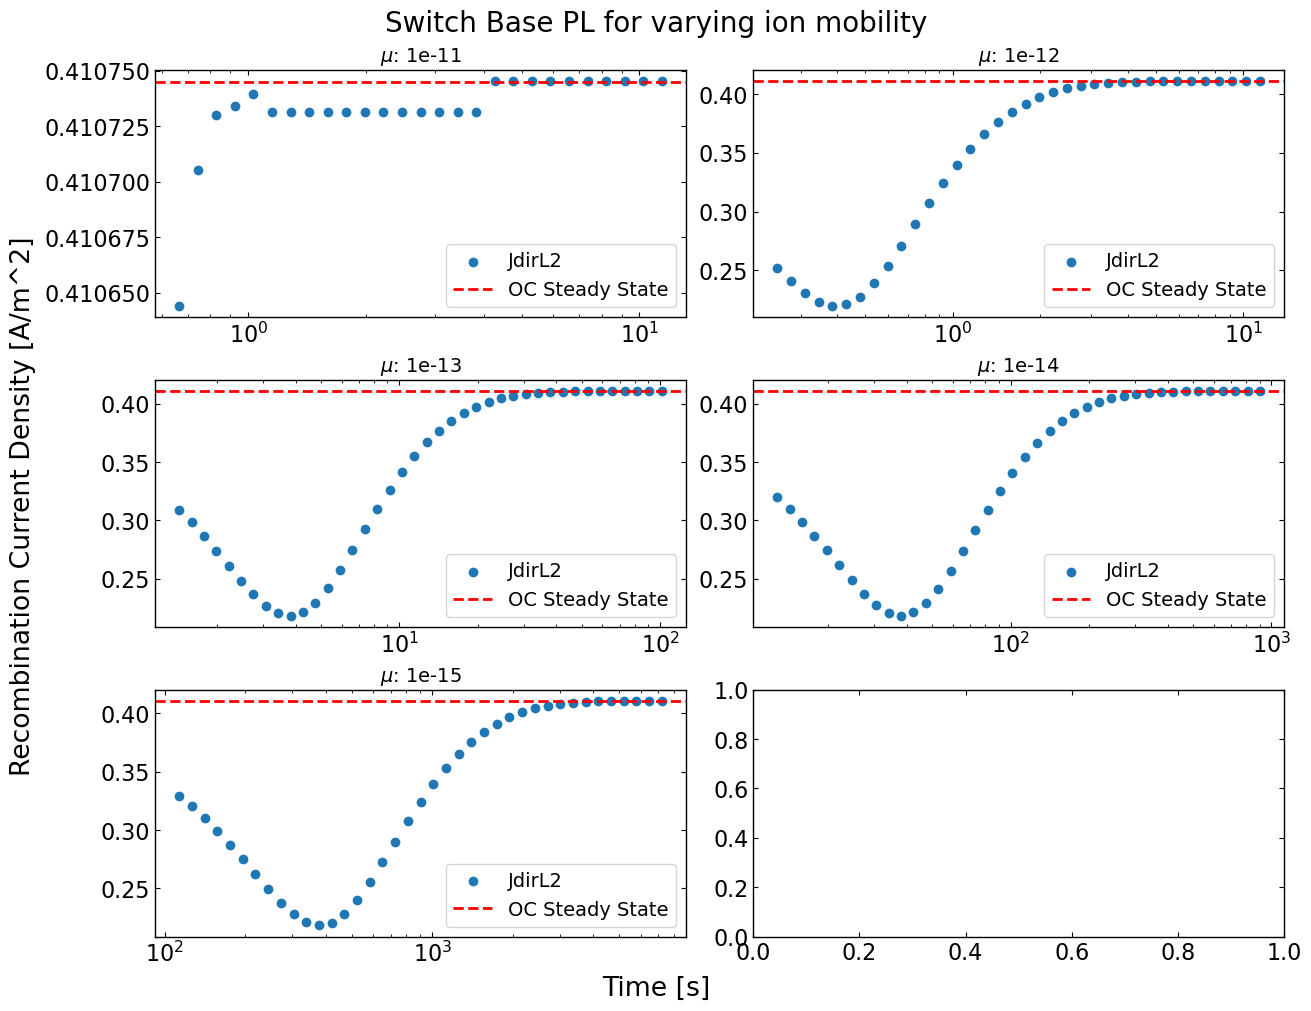

In [14]:
number_of_runs = len(zimt_runs)
cols = 2
rows = number_of_runs // cols if number_of_runs % 2 == 0 else number_of_runs // cols + 1

fig, axes = plt.subplots(rows, cols, layout='constrained', figsize=(13,10))
axes_coords = list(it.product(range(rows), range(cols)))

plot_start_indexes = [13, 4, 20, 40, 60]
plot_end_indexes = [40, 40, 60, 80, 99]

for index, zimt_run in enumerate(zimt_runs):
    ax_row, ax_column = axes_coords[index]
    ax = axes[ax_row][ax_column]
    
    title = f"$\\mu$: {zimt_run.mu_anion}"
    
    plot_start_index = plot_start_indexes[index]
    plot_end_index = plot_end_indexes[index]
    
    # Plot the final JdirL2 value, the OC steady state, as an asymptote
    ax.scatter(zimt_run.tj_data["t"][plot_start_index:plot_end_index], zimt_run.tj_data["JdirL2"][plot_start_index:plot_end_index], label="JdirL2")
    ax.axhline(zimt_run.tj_data["JdirL2"].values[-1], label="OC Steady State", color='red', linestyle='--')
    # ax.axvline(0.2, linestyle='-.', color='black', label='Voc Reached')
    
    ax.set_title(title)
    ax.set_xscale('log')
    ax.legend()
    
fig.suptitle("Switch Base PL for varying ion mobility", fontsize=20)
fig.supxlabel("Time [s]")
fig.supylabel("Recombination Current Density [A/m^2]")
plt.show()

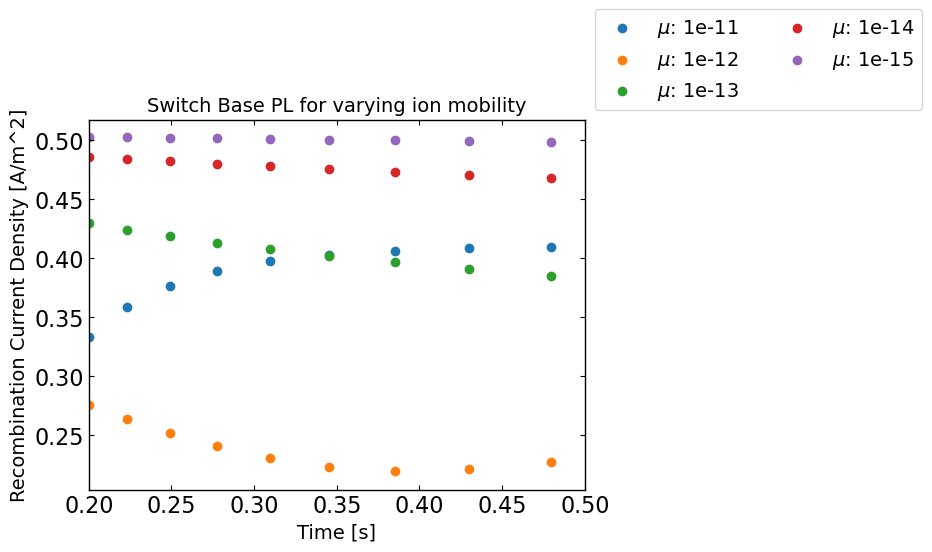

In [15]:
for zimt_run in zimt_runs:
    label = f"$\\mu$: {zimt_run.mu_anion}"
    plt.scatter(zimt_run.tj_data["t"][2:-1], zimt_run.tj_data["JdirL2"][2:-1], label=label)

# plt.axvline(0.1, linestyle='--', color='black') # Mark the initial voltage step
# plt.axvline(0.2, linestyle='--', color='black') # Mark the completion of the transition to Voc
plt.xlabel("Time [s]")
plt.ylabel("Recombination Current Density [A/m^2]")
plt.title("Switch Base PL for varying ion mobility")
plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.xlim((0.2, 0.5))
plt.show()

Here we see several notable effects:
1. Decreasing ion mobility seems to increase the SC steady state radiative recombination, even to being greater the OC radiative recombination
2. Decreasing ion mobility results in a radiative recombination 'trough' that occurs at later times, suggesting mobile response from ions does play a key role in this process.

- Ordinarily, I would expect radiative recombination to be greater at open circuit than at short circuit. Why does that depend on ion mobility? 

I want to check if there's some easy relationship we can draw between the mobility and the peak location and the mobility and the starting recombination.

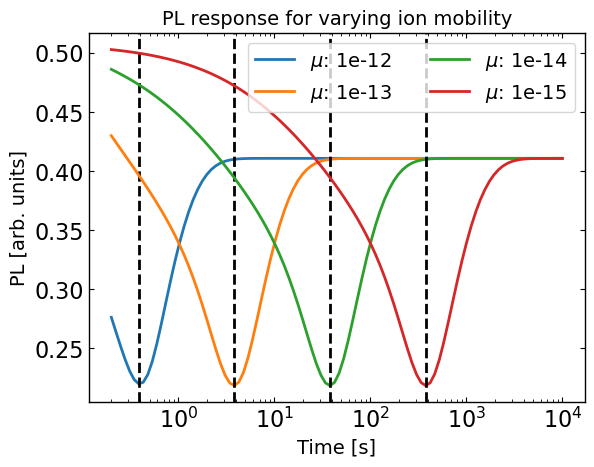

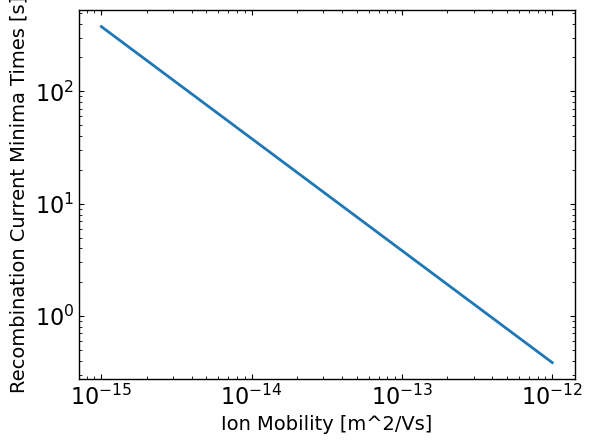

In [16]:
# Try to get some peak times for the different decay processes 
from scipy.signal import find_peaks

recombination_current_trough_indexes = []

for run in zimt_runs[1:]:
    peaks = find_peaks(1/run.tj_data["JdirL2"].values, height=0.1)[0]
    recombination_current_trough_indexes.append(peaks[0])
        
    label = f"$\\mu$: {run.mu_anion}"
    plt.plot(run.tj_data['t'][2:-1],run.tj_data['JdirL2'][2:-1], label=label)
    plt.axvline(run.tj_data['t'][peaks[0]], linestyle='--', color='black')
    
plt.xscale('log')
plt.xlabel("Time [s]")
plt.ylabel("PL [arb. units]")
plt.title("PL response for varying ion mobility")
# plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.legend(ncols=2)
# plt.savefig("PL response for varying ion mobility.pdf", format="pdf")
plt.show()

# Plot peak times against mobility
ion_mobility = [run.mu_anion for run in zimt_runs[1:5]]
recombination_current_trough_times = [run.tj_data['t'][index] for index in recombination_current_trough_indexes]

plt.plot(ion_mobility, recombination_current_trough_times)
plt.xlabel("Ion Mobility [m^2/Vs]")
plt.ylabel("Recombination Current Minima Times [s]")
plt.xscale("log")
plt.yscale("log")
plt.title("")
plt.show()

### Screened Diffusion Explanation
Working explanation of this phenomina:
1. In SC steady state, we expect ionic screening to be maximal in the perovskite close to the interface layers
2. When we switch to OS, these interface layers inhibit the injection of carriers into the transport layers as they screen the built in field, leading to an overshoot in PL.
3. As the ions diffuse away from eachother (which is where mobility comes in), the built in potential increases, improving carrier separation and injection into the transport layers. This separation causes the drop in PL.
4. As time goes on, carrier injection into the transport layers begins to inhibit further seperation, leading to the later rise in PL until steady state is reached.

We can test to see if this is true by plotting the shifting densities with respect to time

Text(0.5, 0.01, 'Ion Density ')

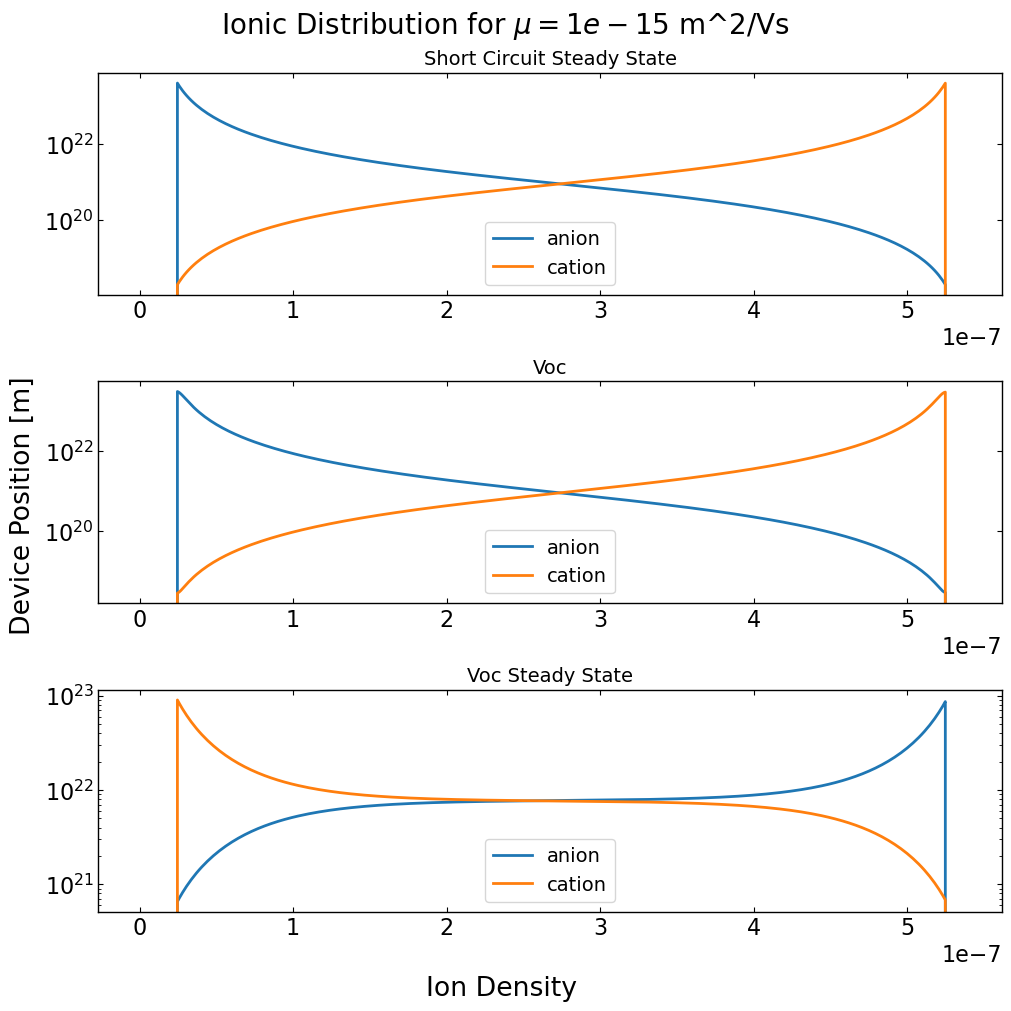

In [17]:
# Get the run at mu=1E-15
ion_mobility = 1E-15
runs = [run for run in zimt_runs if run.mu_anion==1E-15]
run = runs[0]

number_of_x_positions = len(run.var_data["x"].unique())

# Get the internal distributions at short circuit steady state...
internal_distributions_sc_ss = run.var_data.iloc[0:number_of_x_positions]
# print(internal_distributions_sc_ss)

# ...just as we hit Voc...
internal_distributions_oc = run.var_data[run.var_data["time"]==0.2]
# print(internal_distributions_oc)

# ...and at Voc ss
internal_distributions_oc_ss = run.var_data.tail(number_of_x_positions)
# print(internal_distributions_oc_ss)

distributions = [internal_distributions_sc_ss, internal_distributions_oc, internal_distributions_oc_ss]
titles = ["Short Circuit Steady State", "Voc", "Voc Steady State"]


fig = plt.figure(figsize=(10,10), layout="constrained")
for index, distribution in enumerate(distributions):
    subplot_location = f"31{index+1}"
    ax = fig.add_subplot(int(subplot_location))
    ax.plot(distribution["x"], distribution[["anion", "cation"]], label=["anion", "cation"])
    ax.legend()
    ax.set_yscale("log")
    ax.set_title(titles[index])

fig.suptitle(f"Ionic Distribution for $\\mu={ion_mobility}$ m^2/Vs", fontsize=20)
fig.supylabel("Device Position [m]")
fig.supxlabel("Ion Density ")


Text(0.5, 0.01, 'Carrier Density [m^-3]')

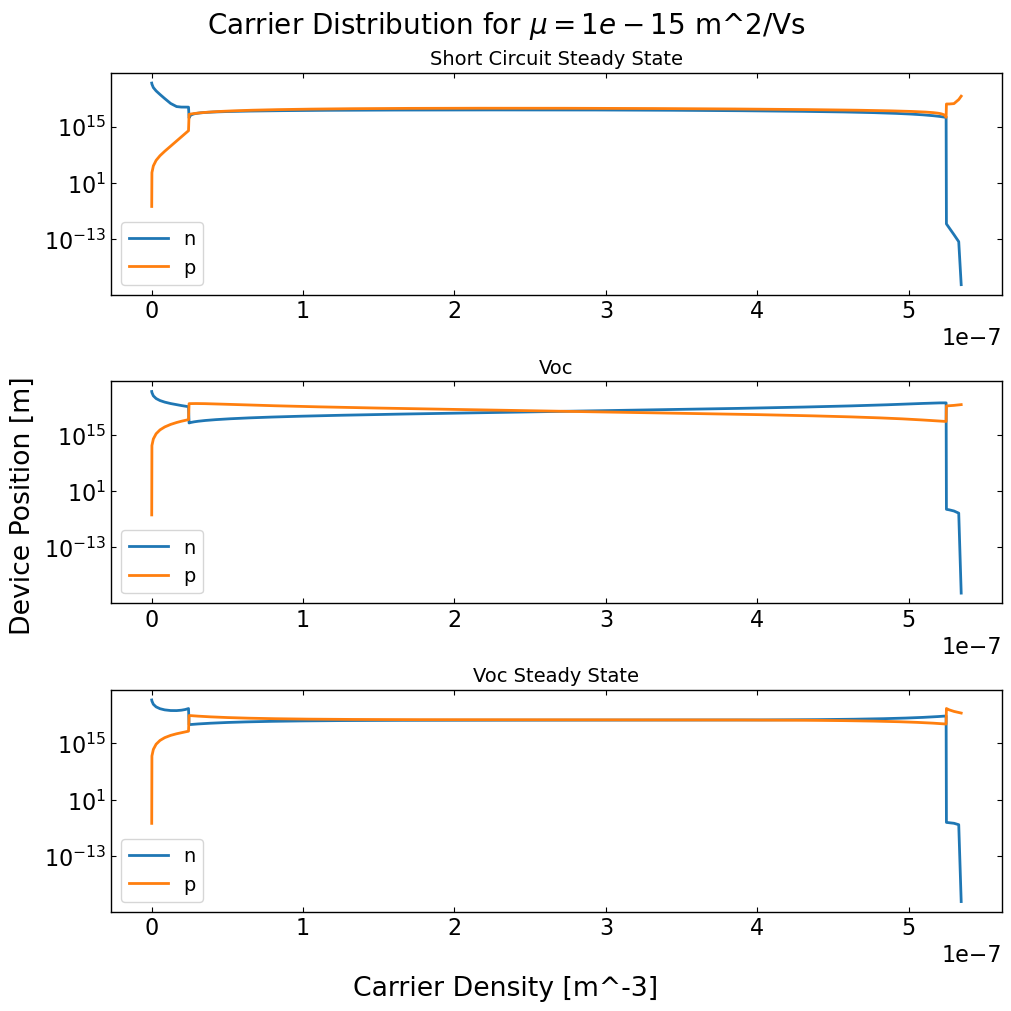

In [18]:
# Same again for carrier distribution
titles = ["Short Circuit Steady State", "Voc", "Voc Steady State"]


fig = plt.figure(figsize=(10,10), layout="constrained")
for index, distribution in enumerate(distributions):
    subplot_location = f"31{index+1}"
    ax = fig.add_subplot(int(subplot_location))
    ax.plot(distribution["x"], distribution[["n", "p"]], label=["n", "p"])
    ax.legend()
    ax.set_yscale("log")
    ax.set_title(titles[index])

fig.suptitle(f"Carrier Distribution for $\\mu={ion_mobility}$ m^2/Vs", fontsize=20)
fig.supylabel("Device Position [m]")
fig.supxlabel("Carrier Density [m^-3]")

Text(0.02, 0.5, 'Potential Density [V]')

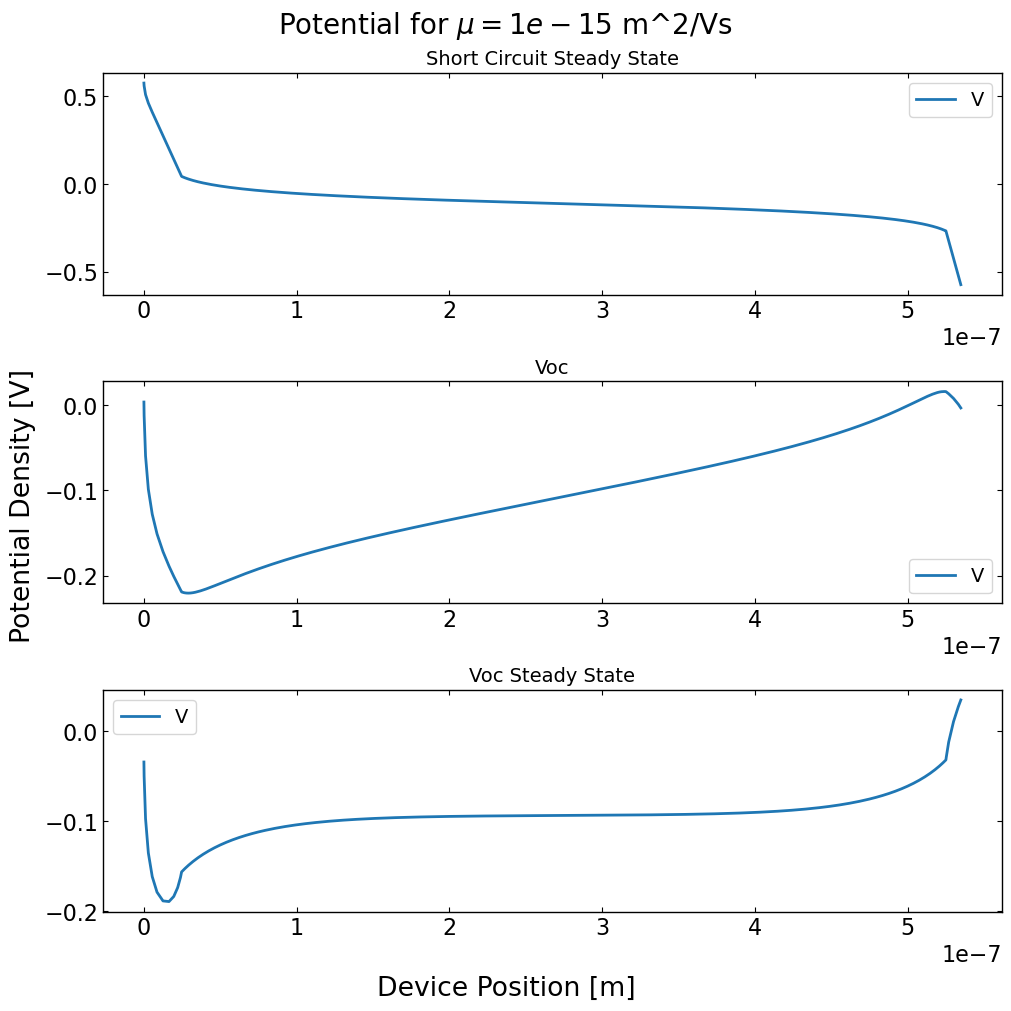

In [19]:
# Same again for carrier distribution
titles = ["Short Circuit Steady State", "Voc", "Voc Steady State"]

fig = plt.figure(figsize=(10,10), layout="constrained")
for index, distribution in enumerate(distributions):
    subplot_location = f"31{index+1}"
    ax = fig.add_subplot(int(subplot_location))
    ax.plot(distribution["x"], distribution["V"], label=["V"])
    ax.legend()
    ax.set_title(titles[index])

fig.suptitle(f"Potential for $\\mu={ion_mobility}$ m^2/Vs", fontsize=20)
fig.supxlabel("Device Position [m]")
fig.supylabel("Potential Density [V]")

### Comparision of Simulated Inflection Point Times and Ion Mobilities to Fransien's Formula

Here, I want to test Fransien's hysterisis formula to see if there's a similar relationship between the ion mobility and the inflection point in these PL graphs

$$\mu_{\text{ion}} = \upsilon_{\text{ion}} \frac{L_{\text{perovskite}}^2}{V^2}$$

$$\Delta t_{\text{ion}} \approx \frac{L_{\text{perovskite}}^2}{\mu_{\text{ion}}V^2}$$

In [20]:
def get_inflection_point_prediciton(ion_mobility: Number, potential: Number, device_length: Number, coefficient: Number = 1) -> Number:
    inflection_point_time = coefficient*device_length**2/(ion_mobility*potential**2)
    return inflection_point_time

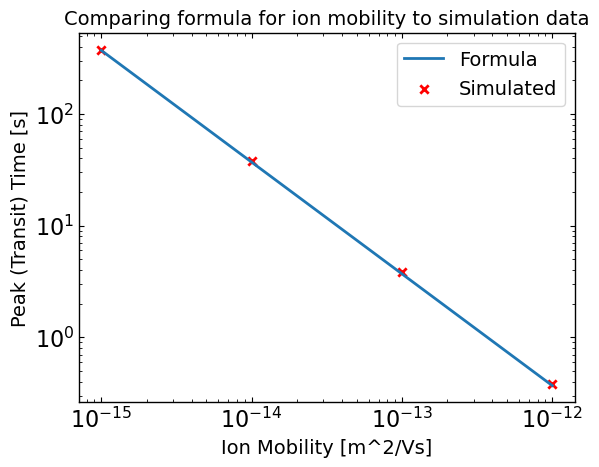

In [21]:
device_length = 500E-9 # m

zimt_runs_short = zimt_runs[1:] # Taking everything from index one as the first curve doesn't have an easily found inflection point 

measured_steady_state_Voc_values = [run.tj_data['Vext'].values[-1] for run in zimt_runs_short]
predicted_inflection_point_times = []

# # Get the Voc for each inflection oin
# measured_inflection_point_Voc = []
# for index, run in enumerate(zimt_runs[1:5]):
#     inflection_point_time_index = recombination_current_trough_indexes[index]
#     inflection_point_Voc = run.tj_data['Vext'][inflection_point_time_index]
#     measured_inflection_point_Voc.append(inflection_point_Voc)

for index, run in enumerate(zimt_runs_short): 
    inflection_point_prediction = get_inflection_point_prediciton(run.mu_anion, measured_steady_state_Voc_values[index], device_length, coefficient=2.2)
    predicted_inflection_point_times.append(inflection_point_prediction)
    
plt.plot(mu_ions[1:], predicted_inflection_point_times, label='Formula')
plt.scatter(mu_ions[1:], recombination_current_trough_times, label='Simulated', marker='x', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Ion Mobility [m^2/Vs]")
plt.ylabel("Peak (Transit) Time [s]")
plt.title("Comparing formula for ion mobility to simulation data")
plt.legend()
plt.show()



We can see that works well for this device. Now we can try it for perovskite thickness to make sure it holds. I've kept ion density fixed at 1E-22 and have varied ion mobility according to the values given above. I will vary perovskite length from 300nm - 600nm in 100nm increments. Run the experiment using

```~$ ./experiment__varying_device_length_and_ion_mobility.sh```

In [22]:
@dataclass
class ZimtRun:
    N_anion: Number
    N_cation: Number
    mu_anion: Number
    mu_cation: Number
    perovskite_thickness: Number
    tj_data: pd.DataFrame

In [23]:
# Read data
perovskite_thicknesses = ["300E-9", "400E-9", "500E-9", "600E-9"]
mu_ions = ["1E-11", "1E-12", "1E-13", "1E-14", "1E-15"]

varying_parameters = it.product(perovskite_thicknesses, mu_ions)

zimt_runs = []

for thickness, ion_mobility in varying_parameters:
    tj_file_name = f"tj_mu_ions_{ion_mobility}_thickness_{thickness}.dat"
    tj_file_data = pd.read_csv(os.path.join(session_path, tj_file_name), sep=r'\s+')
    
    zimt_run = ZimtRun(N_anion=1E22, N_cation=1E22, tj_data=tj_file_data, mu_anion=float(ion_mobility), 
                       mu_cation=float(ion_mobility), perovskite_thickness=float(thickness))
    
    zimt_runs.append(zimt_run)

#### Thickness One - 400E-9m
I started at 400nm as the first thickness simply because it has the same number of inflection points as for the 500nm case

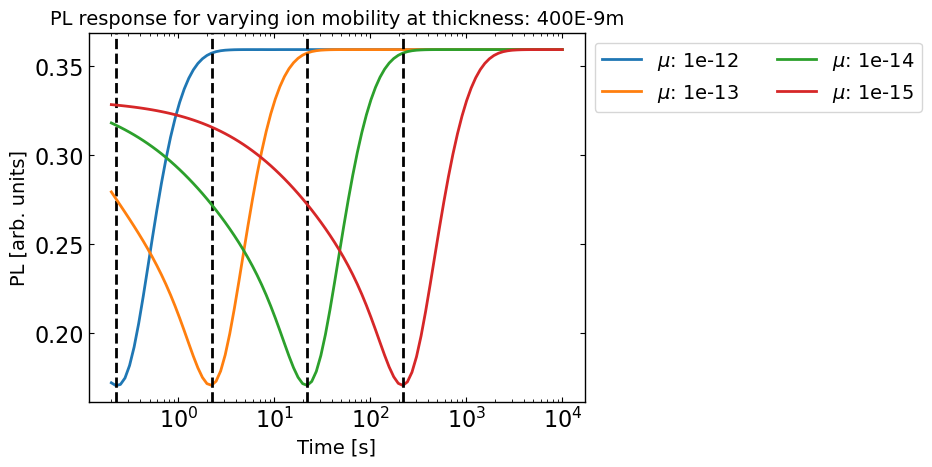

In [24]:
thickness = "400E-9"
runs_at_specified_thickness = [zimt_run for zimt_run in zimt_runs if zimt_run.perovskite_thickness == float(thickness)]

recombination_current_trough_indexes = []

for run in runs_at_specified_thickness[1:]:
    peaks = find_peaks(1/run.tj_data["JdirL2"].values, height=0.1)[0]
    recombination_current_trough_indexes.append(peaks[0])
        
    label = f"$\\mu$: {run.mu_anion}"
    plt.plot(run.tj_data['t'][2:-1],run.tj_data['JdirL2'][2:-1], label=label)
    plt.axvline(run.tj_data['t'][peaks[0]], linestyle='--', color='black')
    
plt.xscale('log')
plt.xlabel("Time [s]")
plt.ylabel("PL [arb. units]")
plt.title(f"PL response for varying ion mobility at thickness: {thickness}m")
plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.show()

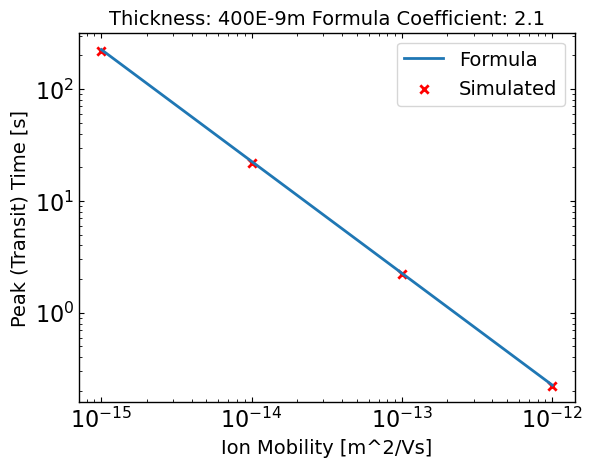

In [25]:
# Plot peak times against mobility
ion_mobility = [run.mu_anion for run in runs_at_specified_thickness[1:5]]
recombination_current_trough_times = [run.tj_data['t'][index] for index in recombination_current_trough_indexes]

runs_at_specified_thickness_short = runs_at_specified_thickness[1:] # Taking everything from index one as the first curve doesn't have an easily found inflection point 

measured_steady_state_Voc_values = [run.tj_data['Vext'].values[-1] for run in runs_at_specified_thickness_short]
predicted_inflection_point_times = []

coefficient = 2.1
for index, run in enumerate(runs_at_specified_thickness_short): 
    inflection_point_prediction = get_inflection_point_prediciton(run.mu_anion, measured_steady_state_Voc_values[index], float(thickness), coefficient=coefficient)
    predicted_inflection_point_times.append(inflection_point_prediction)
    
plt.plot(ion_mobility, predicted_inflection_point_times, label='Formula')
plt.scatter(ion_mobility, recombination_current_trough_times, label='Simulated', marker='x', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Ion Mobility [m^2/Vs]")
plt.ylabel("Peak (Transit) Time [s]")
plt.title(f"Thickness: {thickness}m Formula Coefficient: {coefficient}")
plt.legend()
plt.show()

#### Thickness two - 500nm
Though we plotted this above, I thought I would re-do the work here to keep graph formatting consistent

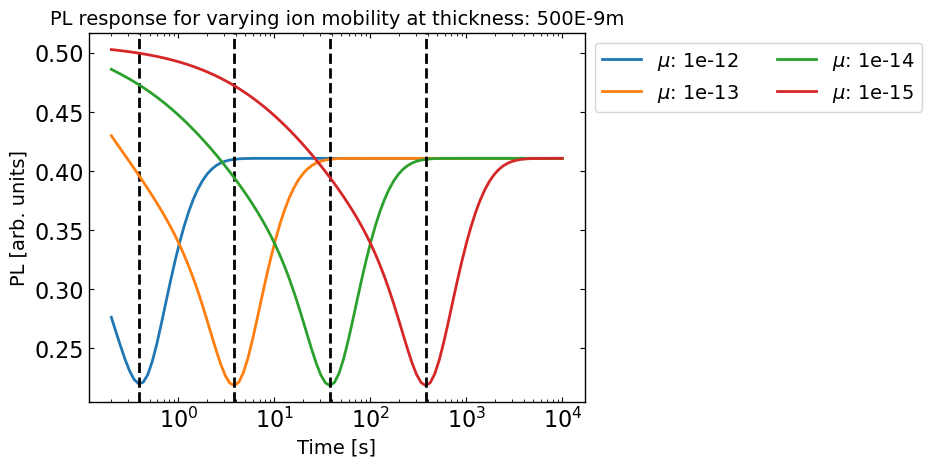

In [26]:
thickness = "500E-9"
runs_at_specified_thickness = [zimt_run for zimt_run in zimt_runs if zimt_run.perovskite_thickness == float(thickness)]

recombination_current_trough_indexes = []

for run in runs_at_specified_thickness[1:]:
    peaks = find_peaks(1/run.tj_data["JdirL2"].values, height=0.1)[0]
    recombination_current_trough_indexes.append(peaks[0])
        
    label = f"$\\mu$: {run.mu_anion}"
    plt.plot(run.tj_data['t'][2:-1],run.tj_data['JdirL2'][2:-1], label=label)
    plt.axvline(run.tj_data['t'][peaks[0]], linestyle='--', color='black')
    
plt.xscale('log')
plt.xlabel("Time [s]")
plt.ylabel("PL [arb. units]")
plt.title(f"PL response for varying ion mobility at thickness: {thickness}m")
plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.show()

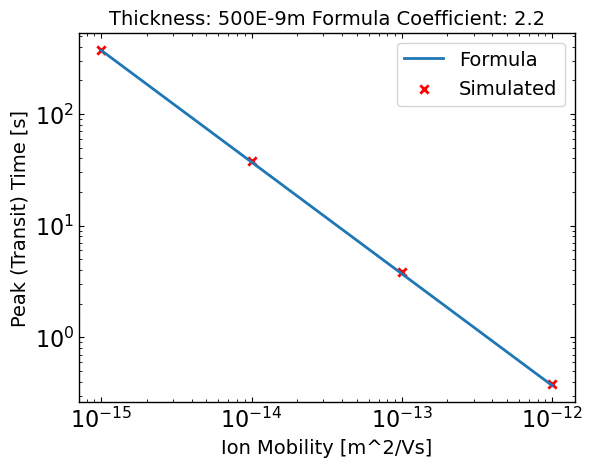

In [27]:
# Plot peak times against mobility
ion_mobility = [run.mu_anion for run in runs_at_specified_thickness[1:5]]
recombination_current_trough_times = [run.tj_data['t'][index] for index in recombination_current_trough_indexes]

runs_at_specified_thickness_short = runs_at_specified_thickness[1:] # Taking everything from index one as the first curve doesn't have an easily found inflection point 

measured_steady_state_Voc_values = [run.tj_data['Vext'].values[-1] for run in runs_at_specified_thickness_short]
predicted_inflection_point_times = []

coefficient = 2.2
for index, run in enumerate(runs_at_specified_thickness_short): 
    inflection_point_prediction = get_inflection_point_prediciton(run.mu_anion, measured_steady_state_Voc_values[index], float(thickness), coefficient=coefficient)
    predicted_inflection_point_times.append(inflection_point_prediction)
    
plt.plot(ion_mobility, predicted_inflection_point_times, label='Formula')
plt.scatter(ion_mobility, recombination_current_trough_times, label='Simulated', marker='x', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Ion Mobility [m^2/Vs]")
plt.ylabel("Peak (Transit) Time [s]")
plt.title(f"Thickness: {thickness}m Formula Coefficient: {coefficient}")
plt.legend()
plt.show()

#### Thickness Three - 600nm
Though we plotted this above, I thought I would re-do the work here to keep graph formatting consistent

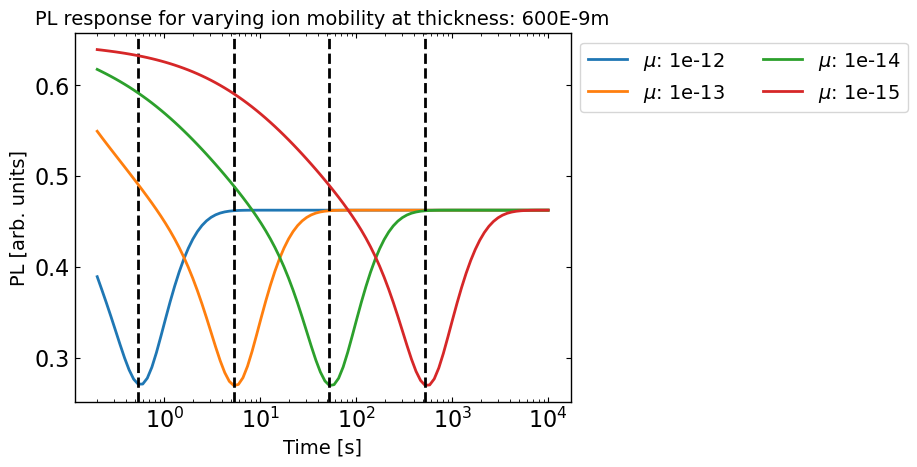

In [28]:
thickness = "600E-9"
runs_at_specified_thickness = [zimt_run for zimt_run in zimt_runs if zimt_run.perovskite_thickness == float(thickness)]

recombination_current_trough_indexes = []

for run in runs_at_specified_thickness[1:]:
    peaks = find_peaks(1/run.tj_data["JdirL2"].values, height=0.1)[0]
    recombination_current_trough_indexes.append(peaks[0])
        
    label = f"$\\mu$: {run.mu_anion}"
    plt.plot(run.tj_data['t'][2:-1],run.tj_data['JdirL2'][2:-1], label=label)
    plt.axvline(run.tj_data['t'][peaks[0]], linestyle='--', color='black')
    
plt.xscale('log')
plt.xlabel("Time [s]")
plt.ylabel("PL [arb. units]")
plt.title(f"PL response for varying ion mobility at thickness: {thickness}m")
plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.show()

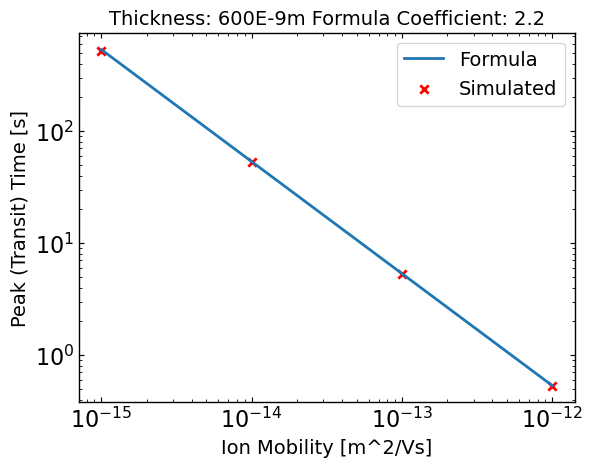

In [29]:
# Plot peak times against mobility
ion_mobility = [run.mu_anion for run in runs_at_specified_thickness[1:5]]
recombination_current_trough_times = [run.tj_data['t'][index] for index in recombination_current_trough_indexes]

runs_at_specified_thickness_short = runs_at_specified_thickness[1:] # Taking everything from index one as the first curve doesn't have an easily found inflection point 

measured_steady_state_Voc_values = [run.tj_data['Vext'].values[-1] for run in runs_at_specified_thickness_short]
predicted_inflection_point_times = []

coefficient = 2.2
for index, run in enumerate(runs_at_specified_thickness_short): 
    inflection_point_prediction = get_inflection_point_prediciton(run.mu_anion, measured_steady_state_Voc_values[index], float(thickness), coefficient=coefficient)
    predicted_inflection_point_times.append(inflection_point_prediction)
    
plt.plot(ion_mobility, predicted_inflection_point_times, label='Formula')
plt.scatter(ion_mobility, recombination_current_trough_times, label='Simulated', marker='x', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Ion Mobility [m^2/Vs]")
plt.ylabel("Peak (Transit) Time [s]")
plt.title(f"Thickness: {thickness}m Formula Coefficient: {coefficient}")
plt.legend()
plt.show()

#### All together 

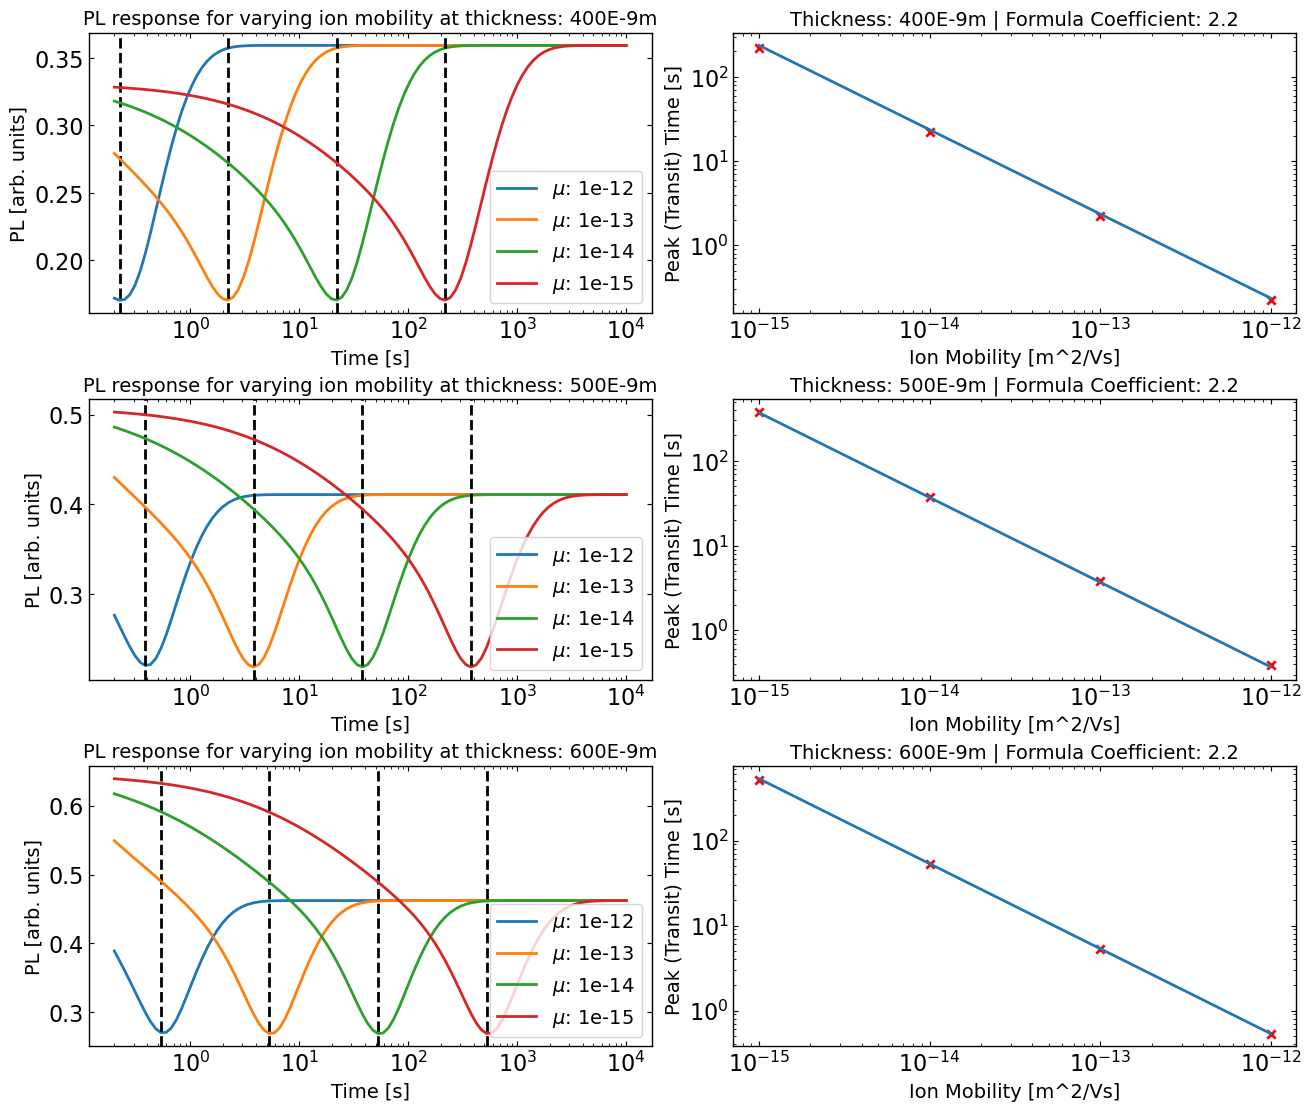

In [30]:
number_of_runs = len(zimt_runs)
cols = 2
rows = len(perovskite_thicknesses[1:])

fig, axes = plt.subplots(rows, cols, layout='constrained', figsize=(13,11))
axes_coords = list(it.product(range(rows), range(cols)))

for index, thickness in enumerate(perovskite_thicknesses[1:]):
    runs_at_specified_thickness = [zimt_run for zimt_run in zimt_runs if zimt_run.perovskite_thickness == float(thickness)]

    # Find peak times
    recombination_current_trough_indexes = []
    peak_axes = axes[index][0]
    
    for run in runs_at_specified_thickness[1:]:
        peaks = find_peaks(1/run.tj_data["JdirL2"].values, height=0.1)[0]
        recombination_current_trough_indexes.append(peaks[0])
            
        label = f"$\\mu$: {run.mu_anion}"
        peak_axes.plot(run.tj_data['t'][2:-1],run.tj_data['JdirL2'][2:-1], label=label)
        peak_axes.axvline(run.tj_data['t'][peaks[0]], linestyle='--', color='black')
        peak_axes.set_xscale('log')
        peak_axes.legend()
        peak_axes.set_xlabel("Time [s]")
        peak_axes.set_ylabel("PL [arb. units]")
        peak_axes.set_title(f"PL response for varying ion mobility at thickness: {thickness}m")
        
        
    # Plot peak times against mobility
    formula_simulation_comparison_axes = axes[index][1]
    ion_mobility = [run.mu_anion for run in runs_at_specified_thickness[1:5]]
    recombination_current_trough_times = [run.tj_data['t'][index] for index in recombination_current_trough_indexes]

    runs_at_specified_thickness_short = runs_at_specified_thickness[1:] # Taking everything from index one as the first curve doesn't have an easily found inflection point 

    measured_steady_state_Voc_values = [run.tj_data['Vext'].values[-1] for run in runs_at_specified_thickness_short]
    predicted_inflection_point_times = []

    coefficient = 2.2
    for index, run in enumerate(runs_at_specified_thickness_short): 
        inflection_point_prediction = get_inflection_point_prediciton(run.mu_anion, measured_steady_state_Voc_values[index], float(thickness), coefficient=coefficient)
        predicted_inflection_point_times.append(inflection_point_prediction)
        
    formula_simulation_comparison_axes.plot(ion_mobility, predicted_inflection_point_times, label='Formula')
    formula_simulation_comparison_axes.scatter(ion_mobility, recombination_current_trough_times, label='Simulated', marker='x', color='red')
    formula_simulation_comparison_axes.set_xscale('log')
    formula_simulation_comparison_axes.set_yscale('log')
    formula_simulation_comparison_axes.set_xlabel("Ion Mobility [m^2/Vs]")
    formula_simulation_comparison_axes.set_ylabel("Peak (Transit) Time [s]")
    formula_simulation_comparison_axes.set_title(f"Thickness: {thickness}m | Formula Coefficient: {coefficient}")
    
# plt.savefig("Relating ion mobility and time shift.pdf", format="pdf")

#### Testing Overshoot Dependence on Critical Ion Concentration
Jan Anton pointed out that the initial PL overshoot seems to depend on device thickness and mobility. He's suggested calculating the critical ion concentration, $N_x$ to see if the magnitude of the PL overshoot is correlated:

$$N_x = \frac{V_{\text{bi}}}{qL_2}(\frac{L_1}{\varepsilon_1} + \frac{L_3}{\varepsilon_3})^{-1}$$

In our case, we can approximate $V_{\text{bi}} \approx V_{\text{oc}}$ and we note $\varepsilon_i=\varepsilon_0 \varepsilon_{r,i}$ 

In [31]:
def get_critical_ion_density(absorber_thickness: Number, short_circuit_potential: Number, layer1_thickness: Number, 
                             layer3_thickness: Number, layer1_permittivity: Number, layer3_permittivity: Number) -> Number:
    q = 1.60217663E-19
    critical_ion_density = (short_circuit_potential/(q*absorber_thickness)) * (layer1_thickness/layer1_permittivity + layer3_thickness/layer3_permittivity)**(-1)
    return critical_ion_density

In [32]:
vacuum_permittivity = 8.8541878188E-12

# Get length and permittivity for layer 1
layer1_thickness = 25E-9 
layer1_relative_permittivity = 5
layer1_permittivity = vacuum_permittivity*layer1_relative_permittivity

# Get length and permittivity for layer 3
layer3_thickness = 10E-9
layer3_relative_permittivity = 3
layer3_permittivity = vacuum_permittivity*layer3_relative_permittivity

# absorber_thickness = 500E-9

critical_ion_densities = []

# Get critical ion densities for all runs at all thicknesses 

for absorber_thickness in perovskite_thicknesses:

    zimt_runs_at_specified_thickness = [run for run in zimt_runs if run.perovskite_thickness == float(absorber_thickness)] 

    for run in zimt_runs_at_specified_thickness:
        # if run.N_anion == float():
        #     continue
        run_steady_state_Voc = run.tj_data["Vext"].values[-1]
        critical_ion_density = get_critical_ion_density(run.perovskite_thickness, run_steady_state_Voc, 
                                                        layer1_thickness, layer3_thickness, layer1_permittivity, layer3_permittivity)
        
        critical_ion_densities.append({
                "absorber thickness": float(absorber_thickness),
                "ion mobility": run.mu_cation,
                "Voc": run_steady_state_Voc,
                "critical ion density" : critical_ion_density
            })

In [33]:
[(critical_ion_density["critical ion density"], critical_ion_density["absorber thickness"]) for critical_ion_density in critical_ion_densities]

[(np.float64(2.698154793381086e+22), 3e-07),
 (np.float64(2.698152916632838e+22), 3e-07),
 (np.float64(2.6981530492652233e+22), 3e-07),
 (np.float64(2.698153002843889e+22), 3e-07),
 (np.float64(2.6981529497909345e+22), 3e-07),
 (np.float64(2.024141524860669e+22), 4e-07),
 (np.float64(2.02414279647366e+22), 4e-07),
 (np.float64(2.024142814710613e+22), 4e-07),
 (np.float64(2.0241427566839445e+22), 4e-07),
 (np.float64(2.024142688709847e+22), 4e-07),
 (np.float64(1.6166439944664444e+22), 5e-07),
 (np.float64(1.6166437252227028e+22), 5e-07),
 (np.float64(1.6166437013488732e+22), 5e-07),
 (np.float64(1.6166429798286989e+22), 5e-07),
 (np.float64(1.616643581979727e+22), 5e-07),
 (np.float64(1.3457077825276628e+22), 6e-07),
 (np.float64(1.3457077946856315e+22), 6e-07),
 (np.float64(1.345707778106583e+22), 6e-07),
 (np.float64(1.3457088568499817e+22), 6e-07),
 (np.float64(1.3457083163730126e+22), 6e-07)]

[[2.69815295e+22 3.00000000e-07]
 [2.02414269e+22 4.00000000e-07]
 [1.61664358e+22 5.00000000e-07]
 [1.34570832e+22 6.00000000e-07]]


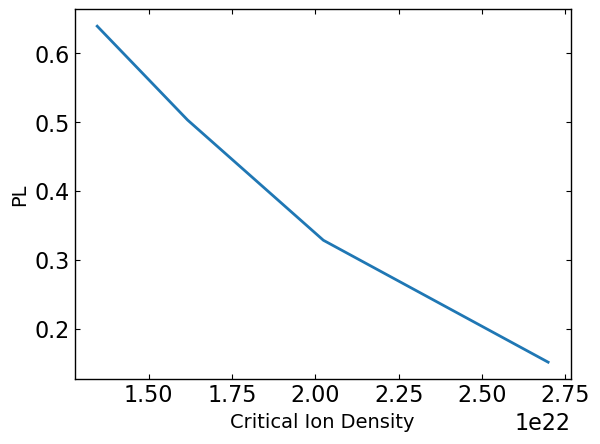

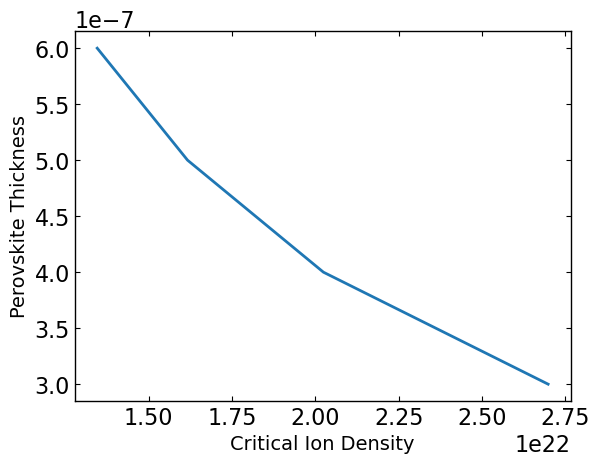

In [63]:
# Plot how 
ion_mobility = 1E-15

critical_ion_densities_at_specific_ion_mobility = [critical_ion_density for critical_ion_density in critical_ion_densities if critical_ion_density["ion mobility"]==ion_mobility]

critical_ion_densities_values = np.array([[critical_ion_density["critical ion density"], critical_ion_density["absorber thickness"]] for critical_ion_density in critical_ion_densities_at_specific_ion_mobility])
print(critical_ion_densities_values)
critical_ion_densities_and_PL = [] 

for critical_ion_density in critical_ion_densities_at_specific_ion_mobility:
    for run in zimt_runs:
        if run.mu_anion != ion_mobility:
            continue
        
        if run.perovskite_thickness != critical_ion_density["absorber thickness"]:
            continue
        
        PL_at_Voc = run.tj_data["JdirL2"].values[2]
        
        critical_ion_densities_and_PL.append([PL_at_Voc, critical_ion_density["critical ion density"], run.perovskite_thickness])
        
critical_ion_densities_and_PL = np.array(critical_ion_densities_and_PL)

# plt.plot(critical_ion_densities_values[:, 1], critical_ion_densities_values[:, 0])
plt.plot(critical_ion_densities_and_PL[:, 1], critical_ion_densities_and_PL[:, 0])
plt.xlabel("Critical Ion Density")
plt.ylabel("PL")
plt.show()

plt.plot(critical_ion_densities_and_PL[:, 1], critical_ion_densities_and_PL[:, 2])
plt.xlabel("Critical Ion Density")
plt.ylabel("Perovskite Thickness")
plt.show()


## Testing System Response for Fixed Ion Mobility 
#### Experiment ID: "supressed_recombination_mu_ion_E-14"

Now that we've found overshoot and undershoot are impacted by ion mobility, we're going to try supressing all recombination coefficients simultaneously.
### Experiment set-up 
Note: for these runs, we'll use the tVG_high_res.dat file as generated before 

In [ ]:
# Generate experimental parameters we will use to write a bash script for running the experiment
# Fixed for the simulation
ion_mobility = 1E-14 
ion_density = 1E22

default_varying_parameters = {
    "l2.k_direct" : 1E-17,
    "l2.C_n_bulk" : 5E-14,
    "l2.C_p_bulk" : 2E-14,
    # Interface recombination at the rightmost interface of the perovskite right
    "l2.C_n_int" : 2E-14,
    "l2.C_p_int" : 2E-14,
    # Interface recombination at the leftmost interface of the perovskite
    "l1.C_n_int" : 2E-14,
    "l1.C_p_int" : 2E-14
}

fixed_parameters = {
    "l2.mu_anion" : ion_mobility,
    "l2.mu_cation" : ion_mobility,
    "l2.N_anion" : ion_density,
    "l2.N_cation" : ion_density
}


experiment_parameters = {}


# Create a constant we'll use to modify recombination over the span of several orders of magnitude
number_of_supression_steps = 10
suppression_factor = np.geomspace(1E0, 1E-5, number_of_supression_steps)

# Add an arrays of fixed parameters to the experiment_parameters dict
# for parameter, value in fixed_parameters.items():
#     value_range = np.array([value for _ in range(number_of_supression_steps)])
#     experiment_parameters[parameter] = value_range
experiment_parameters.update(fixed_parameters)

# Add supressed versions of the default parameters to the experiment parameters
for parameter, value in default_varying_parameters.items():
    parameter_range = value * suppression_factor
    experiment_parameters[parameter] = parameter_range

In [ ]:
suppression_factor

In [ ]:
# From the arguments and values, create a parameter .txt file alongside a .sh file containing all the various experiments to run
import uuid 
import hashlib

def get_UUID_from_string(s: str) -> uuid.UUID:
    '''Creates a UUID object based off a passed string'''
    hex_string = hashlib.md5(s.encode("UTF-8")).hexdigest()
    return uuid.UUID(hex=hex_string)

def generate_experiment_files(experiment_parameters: dict[str, float | np.ndarray], session_path: str, experiment_id: str, 
                              tVG_file: str = "tVG.txt", output_files: dict[str, str] = {"tjFile" : "tj.dat"}) -> str:
    '''Generates a bash script where each line corresponds to a specified experiment alongside a .txt file containing all passed parameters'''
    
    # Set up the header of the space seperated parameter file .txt
    parameter_file_string = "UUID "
    for parameter in experiment_parameters.keys(): 
        parameter_file_string += f"{parameter} "
    parameter_file_string = parameter_file_string.strip() + '\n'
    
    # Set up the experiment_zimt_commands file
    zimt_command = "./zimt"
    zimt_commands_file_string = ""
    
    # Set up the tVG command flag and argument
    tVG_file_command_line_argument = f" -tVGFile {tVG_file}"
    
    # Convert the passed experiment parameters to a dataFrame for easy iteration, and parse each row into the relevant files
    experiment_parameters_dataframe = pd.DataFrame(experiment_parameters)
    for _, run in experiment_parameters_dataframe.iterrows():
        run_parameters = ""
        run_command_line_arguments = ""
        
        for parameter, value in run.items():
            run_parameters += f"{value:.2e} "
            run_command_line_arguments += f" -{parameter} {value:.2e}"
        
        run_uuid = str(get_UUID_from_string(run_parameters))
        run_uuid_savefile_tag = f"_{run_uuid}"
        
        for savefile_flag, savefile_name in output_files.items():
            savefile_name_base, savefile_name_extension = os.path.splitext(savefile_name)
            savefile_name = savefile_name_base + f"__{experiment_id}_" + run_uuid_savefile_tag + savefile_name_extension
            
            run_command_line_arguments += f" -{savefile_flag} {savefile_name}"
            
            
        parameter_file_string += run_uuid + " " + run_parameters.strip() + "\n"
        zimt_commands_file_string += zimt_command + tVG_file_command_line_argument + run_command_line_arguments + "\n"
        
    # Save experiment parameters
    parameter_file_name = f"experiment__{experiment_id}__parameters.txt"
    parameter_file_path = os.path.join(session_path, parameter_file_name)
    with open(parameter_file_path, 'w') as file:
        file.write(parameter_file_string)
        
    # Save zimt commands 
    zimt_commands_file_name = f"experiment__{experiment_id}__zimt_commands.sh"
    zimt_commands_file_path = os.path.join(session_path, zimt_commands_file_name)
    with open(zimt_commands_file_path, 'w') as file:
        file.write(zimt_commands_file_string)
        
    return parameter_file_path

In [ ]:
experiment_id = "supressed_recombination_mu_ion_E-14"
parameter_file_path = generate_experiment_files(experiment_parameters, session_path, experiment_id, tVG_file="tVG_high_res.dat")

### Experiment Execution
We can now run the command file using (assuming the GNU parallel command line tool is installed)

```~$ parallel :::: experiment_supressing_recombination_for_fixed_ion_mobility.sh```

(Run the command below to test output first)

```~$ parallel --dry-run :::: experiment_supressing_recombination_for_fixed_ion_mobility.sh```

### Experiment Analysis
#### Read in data

In [ ]:
# Load Parameter Data, including UUIDs, read in UUID data, and store with params in a dictionary object
experiment_parameter_dataframe = pd.read_csv(parameter_file_path, sep=r'\s+')

# For the sake of clarity, I'll use typing here
type ExperimentDict = dict[str, float | pd.DataFrame]

zimt_runs: list[ExperimentDict] = []

# Store each experimental run, including params and tj_data, as a dict and add to zimt_runs
for _, row in experiment_parameter_dataframe.iterrows():
    zimt_run: ExperimentDict = {}    
    
    for parameter, value in row.items():
        zimt_run[parameter] = value
    
    zimt_run_tj_filename = f"tj__{experiment_id}__{zimt_run["UUID"]}.dat"
    zimt_run_file_path = os.path.join(session_path, zimt_run_tj_filename)
    zimt_run_tj_data = pd.read_csv(zimt_run_file_path, sep=r'\s+')
    zimt_run['tj_data'] = zimt_run_tj_data
    
    zimt_runs.append(zimt_run)

### Analysis

In [ ]:
# Get the maximum value of the direct recombination current to calculate the supression factor later 
maximum_direct_recombination = experiment_parameter_dataframe["l2.k_direct"].max()

for run in zimt_runs:
    run_tj_data = run["tj_data"]
    # Remove the last Voc steady state point from the plotted data
    time = run_tj_data["t"].values[2:-1]
    direct_recombination_current = run_tj_data["JdirL2"][2:-1]
    # Get the supression factor 
    suppression_factor = run["l2.k_direct"]/maximum_direct_recombination
    plt.plot(time, direct_recombination_current, label=f"s: {suppression_factor:.2e}")

plt.xlabel("Time [s]")
plt.ylabel("JdirL2")
plt.title("Recombination Current Density as Recombination processes are suppressed")
plt.xscale("log")
plt.legend(bbox_to_anchor=(1,1))

In [ ]:
number_of_runs = len(zimt_runs)
cols = 2
rows = number_of_runs // cols if number_of_runs % 2 == 0 else number_of_runs // cols + 1

fig, axes = plt.subplots(rows, cols, layout='constrained', figsize=(13,11))
axes_coords = list(it.product(range(rows), range(cols)))

for index, zimt_run in enumerate(zimt_runs):
    ax_row, ax_column = axes_coords[index]
    ax = axes[ax_row][ax_column]
    
    suppression_factor = zimt_run["l2.k_direct"]/maximum_direct_recombination
    
    title = f"$s$: {suppression_factor:.2e}"
    
    zimt_run_tj_data = zimt_run["tj_data"]
    
    # Plot the final JdirL2 value, the OC steady state, as an asymptote
    ax.scatter(zimt_run_tj_data["t"][2:-1], zimt_run_tj_data["JdirL2"][2:-1], label="JdirL2")
    ax.axhline(zimt_run_tj_data["JdirL2"].values[-1], label="OC Steady State", color='red', linestyle='--')
    # ax.axvline(0.2, linestyle='-.', color='black', label='Voc Reached')
    
    ax.set_title(title)
    ax.set_xscale('log')
    ax.legend()
    
fig.suptitle("Recombination Current for varying suppression", fontsize=20)
fig.supxlabel("Time [s]")
fig.supylabel("Recombination Current Density [A/m^2]")
plt.show()

In [ ]:
number_of_runs = len(zimt_runs)
cols = 2
rows = number_of_runs // cols if number_of_runs % 2 == 0 else number_of_runs // cols + 1

fig, axes = plt.subplots(rows, cols, layout='constrained', figsize=(13,11))
axes_coords = list(it.product(range(rows), range(cols)))

for index, zimt_run in enumerate(zimt_runs):
    ax_row, ax_column = axes_coords[index]
    ax = axes[ax_row][ax_column]
    
    suppression_factor = zimt_run["l2.k_direct"]/maximum_direct_recombination
    
    title = f"$s$: {suppression_factor:.2e}"
    
    zimt_run_tj_data = zimt_run["tj_data"]
    
    # Plot the final JdirL2 value, the OC steady state, as an asymptote
    ax.scatter(zimt_run_tj_data["t"][2:-1], zimt_run_tj_data["Vext"][2:-1], label="Vext")
    ax.axhline(zimt_run_tj_data["Vext"].values[-1], label="OC Steady State", color='red', linestyle='--')
    # ax.axvline(0.2, linestyle='-.', color='black', label='Voc Reached')
    
    ax.set_title(title)
    ax.set_xscale('log')
    ax.legend()
    
fig.suptitle("$V_{\\text{ext}}$ for varying suppression", fontsize=20)
fig.supxlabel("Time [s]")
fig.supylabel("Recombination Current Density [A/m^2]")
plt.show()

In [ ]:
number_of_runs = len(zimt_runs)
cols = 2
rows = number_of_runs // cols if number_of_runs % 2 == 0 else number_of_runs // cols + 1

fig, axes = plt.subplots(rows, cols, layout='constrained', figsize=(13,11))
axes_coords = list(it.product(range(rows), range(cols)))

for index, zimt_run in enumerate(zimt_runs):
    ax_row, ax_column = axes_coords[index]
    ax = axes[ax_row][ax_column]
    
    suppression_factor = zimt_run["l2.k_direct"]/maximum_direct_recombination
    
    title = f"$s$: {suppression_factor:.2e}"
    
    zimt_run_tj_data = zimt_run["tj_data"]
    
    # Plot the final JdirL2 value, the OC steady state, as an asymptote
    ax.scatter(zimt_run_tj_data["t"][2:-1], zimt_run_tj_data["Vext"][2:-1], label="Vext")
    ax.axhline(zimt_run_tj_data["Vext"].values[-1], label="OC Steady State", color='red', linestyle='--')
    # ax.axvline(0.2, linestyle='-.', color='black', label='Voc Reached')
    
    ax.set_title(title)
    ax.set_xscale('log')
    ax.legend()
    
fig.suptitle("$V_{\\text{ext}}$ for varying suppression", fontsize=20)
fig.supxlabel("Time [s]")
fig.supylabel("Recombination Current Density [A/m^2]")
plt.show()

In [ ]:
# For the sake of presentation, plot the first of these subplots logarithmically against QFLS and Voc
fig, axes = plt.subplots(3, 1, layout='constrained', figsize=(10,8))

zimt_run = zimt_runs[0]
zimt_run_tj_data = zimt_run["tj_data"]

# Plot JdirL2
jdir_axes = axes[0]
jdir_axes.scatter(zimt_run_tj_data["t"][2:-1], np.log10(zimt_run_tj_data["JdirL2"][2:-1]))

jdir_axes.set_xscale("log")
# jdir_axes.set_yscale("log")
jdir_axes.set_ylabel("log(PL) [arb. units]")

# Plot QFLS
qfls_axes = axes[1]
qfls_axes.scatter(zimt_run_tj_data["t"][2:-1], zimt_run_tj_data["QFLSL2"][2:-1])

qfls_axes.set_xscale("log")
qfls_axes.set_ylabel("QFLS [eV]")

# Plot Voc 
Voc_axes = axes[2]
Voc_axes.scatter(zimt_run_tj_data["t"][2:-1], zimt_run_tj_data["Vext"][2:-1])

Voc_axes.set_xscale("log")
Voc_axes.set_ylabel("$V_{\\text{oc}}$ [V]")
Voc_axes.set_xlabel("Time [s]")

fig.suptitle("A Comparison of Measures", fontsize=20)

# fig.savefig("A Comparision of Measures.pdf", format="pdf")